In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

df = pd.DataFrame({
    "Hours_Studied": [
        1, 2, 2, 3, 3,
        4, 4, 5, 5, 6,
        6, 7, 7, 8, 8
    ],

    "Attendance": [
        50, 55, 60, 60, 65,
        65, 70, 70, 75, 75,
        80, 80, 85, 90, 95
    ],

    "Performance": [
        "Fail", "Fail", "Fail", "Fail", "Average",
        "Average", "Average", "Average", "Average", "Excellent",
        "Excellent", "Excellent", "Excellent", "Excellent", "Excellent"
    ]
})

In [7]:
X =df.drop(columns=["Performance"])
y=df["Performance"]

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.5, random_state=42)

In [9]:
model = LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [28]:
y_predict = model.predict(X_test)
print(y_predict)
print(y_test)

['Average' 'Excellent' 'Fail' 'Excellent' 'Average' 'Average' 'Fail'
 'Fail']
9     Excellent
11    Excellent
0          Fail
13    Excellent
5       Average
8       Average
2          Fail
1          Fail
Name: Performance, dtype: str


In [11]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predict)
cm

array([[2, 0, 0],
       [1, 2, 0],
       [0, 0, 3]])

Text(50.83333333333333, 0.5, 'Actual')

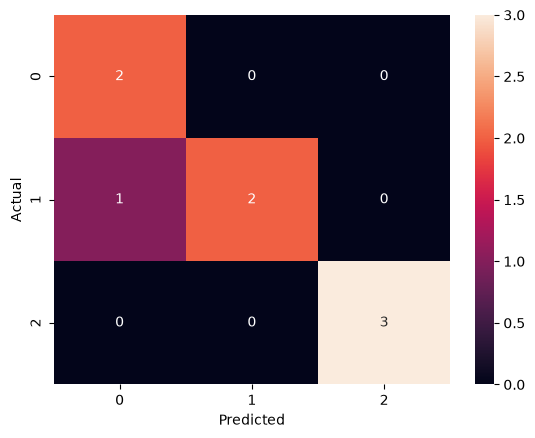

In [12]:
from matplotlib import pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True)
plt.xlabel("Predicted")
#note xlabel is always predicted
plt.ylabel("Actual")


In [13]:
from sklearn.metrics import classification_report
# classificatin report for test
report = classification_report(y_test, y_predict)
print(report)

              precision    recall  f1-score   support

     Average       0.67      1.00      0.80         2
   Excellent       1.00      0.67      0.80         3
        Fail       1.00      1.00      1.00         3

    accuracy                           0.88         8
   macro avg       0.89      0.89      0.87         8
weighted avg       0.92      0.88      0.88         8



In [ ]:
# Class order used by the model
print(model.classes_)
# ['Average' 'Excellent' 'Fail']  => 0, 1,2



['Average' 'Excellent' 'Fail']


In [ ]:
#accurace is for all 
accuracy = (2+2+3)/(2+0+0+1+2+0+0+0+3)
print(accuracy)
#presision for average 0
# precision =>out of total average predected  how many are true 
#recall -> out of total acutal average , how many are true

# or say
# Precision: % of predicted  that are correct with respect to actual
# Recall: % of actual  that are correct with respect to predicted
precision = 2/(0+1+2)
recall = 2/(2+0+0)
f1_score = 2*precision*recall/(precision+recall)
print(precision)
print(recall)
print(f1_score)
#support means total number of 0, 1, 2 in test sample (in acutual test data)
#micro average is just an average simple a+b+c/3 
#weighted average meaans the average comes by giveing weight


0.875
0.6666666666666666
1.0
0.8
